In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
#matplotlib==3.10.0
#numpy==2.2.1
#pandas==2.2.3
#requests==2.32.3
#scikit-learn==1.6.0
#scipy==1.14.1
#seaborn==0.13.2
#statsmodels==0.14.4
#tqdm==4.67.1

In [3]:
import tmdbdata as td
import genderprediction as gp 

import requests
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random
import ast
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
from itertools import combinations

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA

# Mise en contexte

Il est dimanche soir, assis sur son canapé, Jean allume son ordinateur et se connecte à son site de streaming préféré. Après avoir refusé quelques publicités et pop-ups douteux, une myriade de films se proposent à lui. Face à un tel embarras du choix, entre les Tuches 7 et The Dark Knight, Jean hésite... . 

C'est que sur ce site il n'y a pas toutes les informations qu'il voudrait avoir. Certes, il a la date de sortie des films, leur synopsis ou encore leur durée, mais quid de leur qualité, ou de leur genre? 

Au fond, il doit bien y avoir des indices qui permettent d'inférer sur la qualité ou sur certaines propriétés d'un film. 

**Que peut-on dire d'un film sans l'avoir vu?**

Ni une ni deux, Jean se met à coder!

# Présentation générale du projet 

## Les données

Pour ce projet, nous avons décidé de travailler avec deux sources de données:

- The Movie Database (TMDB), qui comme son nom l'indique est une base de données sur le cinéma mondial (et les séries). Il dispose d'une API gratuite, fonctionnelle et facile d'utilisation.
- Data.gouv.fr et en particulier son fichier Lieux de tournage à Paris 

## Le Plan

**I - Récupération des données et statistiques descriptives**

**II - Prédire la note d'un film à l'aide de l'économétrie** 

**III - Prédire le genre d'un film à l'aide de forêts aléatoires**

**IV - L'influence du lieu de tournage sur les caractéristiques d'un film**

# I - Récupération des données et statistiques descriptives

## A - Récupération et traitement des données

Dans cette partie on ne s'intéresse qu'aux données issues de TMDB. 

La majorité des fonctions permettant de récolter les données et de les traiter se trouvent dans le code tmdbdata (td), nous les appellerons à plusieurs reprises dans ce Notebook.

Nous utilisons deux méthodes de l'API de TMDB:  "Discover Movies" et "Movies Details". La première nous permet de récolter rapidement de l'information sur des films en fonction de certains filtres et selon un certain classement. Malheureusement, cette méthode ne permet pas de récolter toute l'information disponible pour chaque film: elle ne capture par exemple ni le budget ni le revenu du film. C'est la deuxième méthode qui le permet: à partir de l'identifiant TMDB d'un film, elle renvoie toutes les informations disponibles sur ce film. 

La récolte des données se fait donc toujours en deux temps. Dans un premier temps on récupère les identifiants des films qui nous intéressent pour notre modèle grâce à Discover movies. Puis pour chaque identifiant on récolte les données spécifiques du film en question grâce à "Movie Details".

Pour cette première partie, on va prendre comme échantillon, les films en anglais les plus notés (avec le plus d'avis laissés par les utilisateurs) sur TMDB. 


In [4]:
ids= td.get_movie_ids_list(1, headers=td.headers) # tire la première page des films US les plus notés, il y a 20 films par page.
df=td.get_movies_info(ids,headers=td.headers)

getting movie ids


100%|██████████| 1/1 [00:00<00:00,  1.41it/s]


getting movie info


100%|██████████| 20/20 [00:02<00:00,  7.80it/s]


En remplaçant 1 par 20, on récupère les 400 films contenus dans usbestmovies. 

In [5]:
df=pd.read_csv("usbestmovies.csv")

On récupère un data-frame avec beaucoup de données inutiles pour notre analyse et pas nécessairement très lisible, on va donc le nettoyer à l'aide de différentes fonctions: on se débarasse des données inutiles, on recode la date de sortie et le genre...

In [ ]:
df.head(2)

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,status,tagline,title,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path
0,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,NaN,160000000,"[{'id': 28, 'name': 'Action'}, {'id': 878, 'na...",https://www.warnerbros.com/movies/inception,27205,tt1375666,"['US', 'GB']",en,...,Released,Your mind is the scene of the crime.,Inception,False,8.37,36731,NaN,NaN,NaN,NaN
1,False,/9REO1DLpmwhrBJY3mYW5eVxkXFM.jpg,NaN,165000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 18, '...",http://www.interstellarmovie.net/,157336,tt0816692,['US'],en,...,Released,Mankind was born on Earth. It was never meant ...,Interstellar,False,8.40,35892,NaN,NaN,NaN,NaN


In [ ]:
df=td.clean_data(df) #nettoyage général des données
df.head(2)

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
0,160000000,27205,"Cobb, a skilled thief who commits corporate es...",117.816,2010-07-15,825532764,148,Inception,8.37,36731,28,Action,https://image.tmdb.org/t/p/original//oYuLEt3zV...,280,9,1279152000
1,165000000,157336,The adventures of a group of explorers who mak...,258.255,2014-11-05,701729206,169,Interstellar,8.40,35892,12,Adventure,https://image.tmdb.org/t/p/original//gEU2QniE6...,198,12,1415145600


## B - Statistiques descriptives

Pour cette partie, on va encore simplifier notre data-frame.

En explorant les données on se rend compte que beaucoup de films n'ont pas d'information quant à leur budget ou leur revenu (affiché comme étant 0). On décide donc de remplacer ces 0 par la moyenne des films dont on connaît cette information

In [8]:
df["revenue"] = df["revenue"].replace(0, df["revenue"][df["revenue"] != 0].mean())
df["budget"] = df["budget"].replace(0, df["budget"][df["budget"] != 0].mean())

Enfin, pour le modèle économétrique qui suivra bientôt on encode la colonne "main_genre_name" par la méthode : "One hot encoding".
De plus on ne garde dans cette partie que les données suivante: genre, id, vote moyen, budget, durée, longueur du synopsis, revenu.

In [9]:
genre_columns=[]
for genre in df["main_genre_name"].unique() :
    df["main_genre_name"+"_"+str(genre)] = (df["main_genre_name"] == genre).astype(int) 
    genre_columns.append("main_genre_name"+"_"+str(genre))
var_explicative=["id","vote_average","budget","runtime","overview_count","revenue"]
var_explicative.extend(genre_columns)
df=df.loc[:,var_explicative]
df.head(2)

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
0,27205,8.37,160000000.0,148,280,825532764.0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,157336,8.40,165000000.0,169,198,701729206.0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


On commence par étudier la dispersion des variables.

In [10]:
df.describe()

,id,vote_average,budget,runtime,overview_count,revenue,main_genre_name_Action,main_genre_name_Adventure,main_genre_name_Drama,main_genre_name_Science Fiction,...,main_genre_name_Animation,main_genre_name_Fantasy,main_genre_name_Family,main_genre_name_Horror,main_genre_name_Mystery,main_genre_name_Western,main_genre_name_History,main_genre_name_Music,main_genre_name_War,main_genre_name_Romance
count,400.000000,400.000000,4.000000e+02,400.000000,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,...,400.000000,400.000000,400.00000,400.00000,400.000000,400.0000,400.0000,400.000000,400.000000,400.000000
mean,129510.180000,7.466062,1.027915e+08,125.272500,292.262500,5.384871e+08,0.275000,0.167500,0.150000,0.060000,...,0.072500,0.047500,0.02500,0.02500,0.015000,0.0025,0.0025,0.005000,0.010000,0.020000
std,167714.533441,0.603830,7.950942e+07,23.109161,132.497084,4.247439e+08,0.447073,0.373889,0.357519,0.237784,...,0.259639,0.212972,0.15632,0.15632,0.121705,0.0500,0.0500,0.070622,0.099623,0.140175
min,11.000000,5.785000,8.069470e+05,76.000000,58.000000,2.859750e+06,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
25%,770.500000,7.038750,3.000000e+07,108.750000,184.750000,2.449317e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
50%,46607.000000,7.496500,9.000000e+07,123.000000,280.000000,4.483672e+08,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
75%,262653.750000,7.915250,1.540000e+08,137.000000,370.250000,7.507392e+08,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.00000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000
max,872585.000000,8.708000,4.600000e+08,242.000000,902.000000,2.923706e+09,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.00000,1.000000,1.0000,1.0000,1.000000,1.000000,1.000000


On peut ensuite voir comment nos variables sont corrélées entre elles (pour le genre on prend l'exemple des drames) 

/tmp/ipykernel_131124/534337137.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)


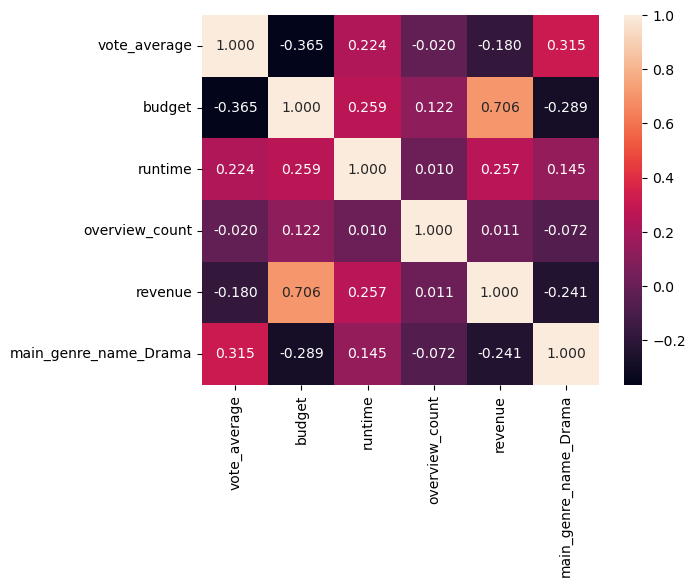

In [11]:
corr = np.corrcoef(df.loc[:, ["vote_average", "budget", "runtime", "overview_count", "revenue", "main_genre_name_Drama"]].T, bias=True)

labs = ['vote_average', 'budget', 'runtime', 'overview_count', 'revenue', 'main_genre_name_Drama']

sns.heatmap(corr, annot=True, fmt='.3f', xticklabels=labs, yticklabels=labs)

plt.show()

On a des résultats qui sont pour certains attendus : corrélation proche de 1 pour le revenu et pour le budget. D'autres qui sont plus surprenants, en particulier budget et note moyenne sont négativement corrélés.

On peut visualiser cette corrélation négative surprenante grâce à un nuage de points. On peut aussi visualiser la faible corrélation entre notes et longueur du film de la même manière.

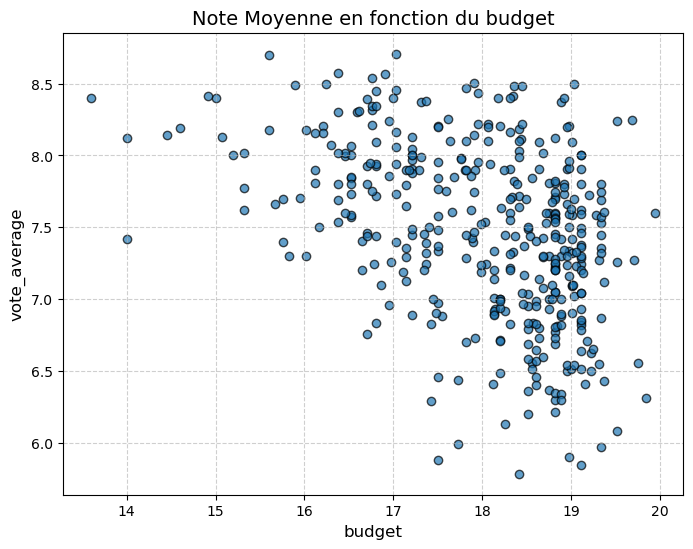

In [12]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df['budget']), df['vote_average'], alpha=0.7, edgecolor='k')

plt.title("Note Moyenne en fonction du budget", fontsize=14)
plt.xlabel("budget", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

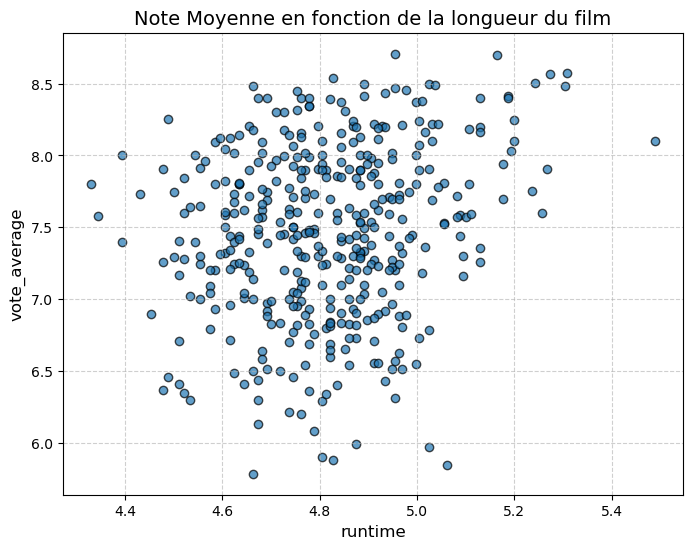

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df['runtime']), df['vote_average'], alpha=0.7, edgecolor='k')

plt.title("Note Moyenne en fonction de la longueur du film", fontsize=14)
plt.xlabel("runtime", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Enfin, on peut regarder comment se répartissent les genres de film dans nos données.

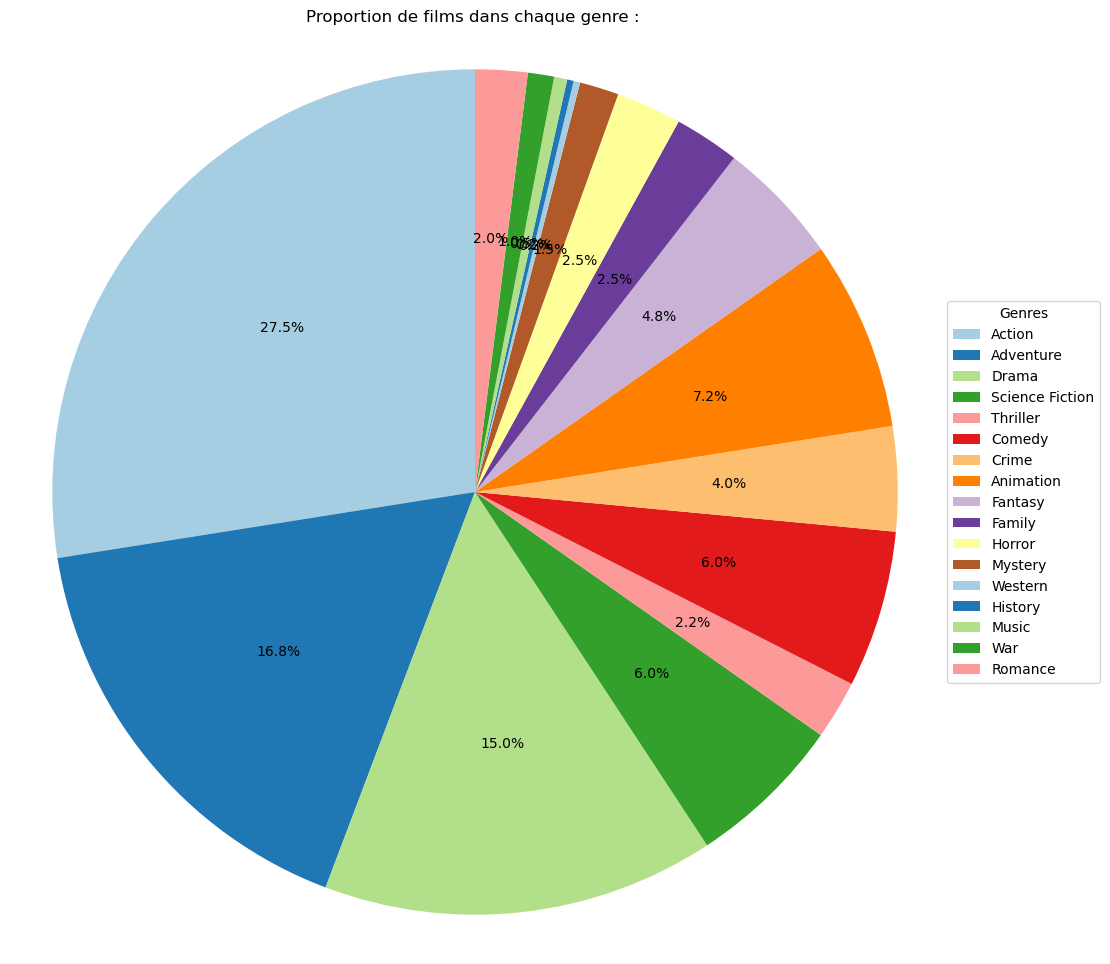

In [14]:
genre_counts = df[genre_columns].sum()
genre_proportions = genre_counts / genre_counts.sum()
genre_labels = [genre.split("main_genre_name_")[1] for genre in genre_proportions.index]
plt.figure(figsize=(12,12))
wedges, texts, autotexts = plt.pie(genre_proportions, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

plt.legend(wedges, genre_labels, title="Genres", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('Proportion de films dans chaque genre : ')
plt.axis('equal')  
plt.show()

On constate que certains genres sont clairement plus présents que d'autres dans nos données, en particulier les films d'action, d'aventure et les drames. C'est plutôt cohérent avec le fait que ce jeu de données soit essentiellement composé de block-busters holywoodiens. 

# II - Prédire la note d'un film à l'aide de l'économétrie

On cherche maintenant à prédire la note moyenne d'un film à partir des autres données. Pour cela nous appliquons les notions d'économétrie que nous avons vues en cours ce semestre.
On garde le même data-frame "df" que précédemment.

NB : La normalisation et la standardisation des données n'est pas nécessaire dans la regression linéaire. En effet, contrairement au modèle de clustering, la regression linéaire ne sélectionne pas les covariables par leurs poids. 

## A - Première régression

On réalise une première régression linéaire sur nos données (hors ID).

In [ ]:
X=df.loc[:,~df.columns.isin(['id', 'vote_average']) ] #données explicatives
Y=df[["vote_average"]] #variable d'intérêt

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2,random_state=42) # 80% de notre échantillon est utilisé pour estimer les coefs de la regression linéaire 

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Variables de la régression linéaire: ", df.columns[2:] )
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Erreur absolue moyenne (MAE) : {mae}")
print(f"Score R2 : {r2}")

Variables de la régression linéaire:  Index(['budget', 'runtime', 'overview_count', 'revenue',
       'main_genre_name_Action', 'main_genre_name_Adventure',
       'main_genre_name_Drama', 'main_genre_name_Science Fiction',
       'main_genre_name_Thriller', 'main_genre_name_Comedy',
       'main_genre_name_Crime', 'main_genre_name_Animation',
       'main_genre_name_Fantasy', 'main_genre_name_Family',
       'main_genre_name_Horror', 'main_genre_name_Mystery',
       'main_genre_name_Western', 'main_genre_name_History',
       'main_genre_name_Music', 'main_genre_name_War',
       'main_genre_name_Romance'],
      dtype='object')
Coefficients de la régression linéaire : [[-3.47191760e-09  1.00467868e-02  3.21678318e-04  1.75886077e-10
  -3.15919748e-01 -1.73506371e-01  2.00993592e-01 -2.19129692e-01
  -3.11557486e-01 -1.68768825e-02  1.43006865e-01  4.46786889e-01
  -3.93967619e-02 -2.20042830e-01 -1.44739533e-01  2.29252040e-01
   1.38777878e-17  3.23528638e-01 -1.63461881e-01  1.440

Quelques interpretations : 
Le coef des MCO devant la variable "budget" peut s'interpreter comme suit : chaque million de dollars supplémentaires réduit la note moyenne d'environ 0.0033.
Le coef des MCO devant la variable "runtime" peut s'interpreter comme suit : une augmentation de 10 minutes dans la durée d'un film est associée à une augmentation de 0.101 dans la variable dépendante "vote_average"

Remarque : les coefficients devant les covariables budget, revenue, ect ... Sont relativement petit comparé aux coefficients devant le genre car par ex la variable budget prend des valeurs très grandes.  

Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [ ]:
# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)

                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.336
Method:                 Least Squares   F-statistic:                     11.08
Date:                Sun, 29 Dec 2024   Prob (F-statistic):           1.91e-27
Time:                        12:26:53   Log-Likelihood:                -273.19
No. Observations:                 400   AIC:                             588.4
Df Residuals:                     379   BIC:                             672.2
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

La différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 70% sur sklearn. Notons que les statistiques de test, sont en valeur absolu relativement élevés ce qui signifie qu'elles sont significatives. 


In [17]:
#Zone de rejet de niveau 5% pour notre test d'hypothèse (H0: B0 =0) :
var_non_significative_au_niv_5=[] 
quant = norm.ppf(1-5/200, loc=0, scale=1)
for var in X.columns:
    if  model.tvalues[var] >= quant or model.tvalues[var] <= - quant : 
        print("On rejette H0, ie que la covariable ", var, "a un impact sur la variable vote_average, ",var," est significative au niveau 5%")
    else: 
        var_non_significative_au_niv_5.append(var)
print(var_non_significative_au_niv_5)


On rejette H0, ie que la covariable  const a un impact sur la variable vote_average,  const  est significative au niveau 5%
On rejette H0, ie que la covariable  budget a un impact sur la variable vote_average,  budget  est significative au niveau 5%
On rejette H0, ie que la covariable  runtime a un impact sur la variable vote_average,  runtime  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Adventure a un impact sur la variable vote_average,  main_genre_name_Adventure  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Drama a un impact sur la variable vote_average,  main_genre_name_Drama  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Comedy a un impact sur la variable vote_average,  main_genre_name_Comedy  est significative au niveau 5%
On rejette H0, ie que la covariable  main_genre_name_Crime a un impact sur la variable vote_average,  main_genre_name_Crime  est significative a

La variable explicative "revenue" est non significative au niveau 5%, ce qui peut etre du à sa forte corrélation à la variable "budget". En effet dans la regression de "vote_average" sur "revenue", celle-ci est significative au niveau 5%, ceci est du au biais de la variable omise. "Pour ce qui est de la non significativité des variables de genres au niveau 5% elle peut etre lié à un échantillon trop fiable de film correspond à ce genre. 

## B- Prédiction optimale :

In [18]:
def generate_combinations(elements, k):
    """
    Génère toutes les combinaisons de k éléments dans une liste donnée.
    
    :param elements: Liste d'éléments (par exemple, une liste de variables).
    :param k: Nombre d'éléments à sélectionner.
    :return: Liste de tuples, chaque tuple représentant une combinaison.
    """
    return list(combinations(elements, k))



Ajouter des variables permet au depart de capter une partie de Y mais en ajouter trop conduit au "surapprentissage". 
Validation croisée : 

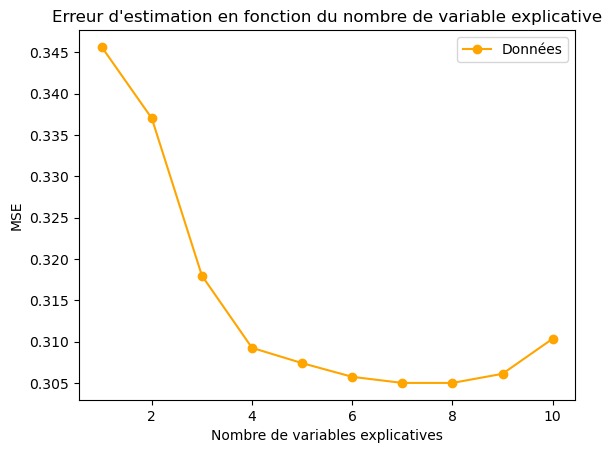

Le sous ensemble de variable explicative minimisant l'erreur de prédiction est : ('budget', 'runtime', 'main_genre_name_Drama', 'main_genre_name_Crime', 'main_genre_name_Animation', 'main_genre_name_Fantasy', 'main_genre_name_Family')


In [19]:
X=df.loc[:,~df.columns.isin(['id', 'vote_average'])]
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) #Cela garantit que la séparation sera toujours la même à chaque exécution du code, ce qui rend les résultats reproductibles.
a=[]
b=[]
c=[]
var_explicative = [x for x in var_explicative if x not in ['id', 'vote_average'] and x not in var_non_significative_au_niv_5]
for i in range(1,len(var_explicative)+1): 
    combinations_list = generate_combinations(var_explicative, i) 
    L=[]
    L_comb=[]
    for comb in combinations_list: 

        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
        L_comb.append(comb)
    a.append(i)
    b.append(min(L))
    c.append(L_comb[L.index(min(L))])

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()
print("Le sous ensemble de variable explicative minimisant l'erreur de prédiction est :",c[b.index(min(b))])

On effectue donc cette regression

In [20]:
X=df.loc[:, c[b.index(min(b))] ]
Y=df[["vote_average"]]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3) # 70% de notre échantillon est utilisé pour estimer les coefs de la regression linéaire 

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Erreur absolue moyenne (MAE) : {mae}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-2.90398782e-09  1.08447658e-02  3.15382140e-01  3.93594633e-01
   6.39379413e-01 -3.12785521e-02  2.73533255e-01]]
Ordonnée à l'origine (intercept) : [6.28820484]
Erreur quadratique moyenne (MSE) : 0.2914277893650933
Erreur absolue moyenne (MAE) : 0.424509185303833
Score R2 : 0.28512593487080484


On obtient une meilleure erreur que lors de la première régression

Attention : ces résultats sont potentiellement biaisés du fait que les films sélectionnées sont des films populaires avec de nombreux votes. Une étude plus approfondie avec une diversité plus grandes des films, c'est à dire avec des films ayant de très mauvaises notes et de très bonnes notes serait pertinente. Cependant l'API ne nous fournit que des films populaires rendant impossible ces ouvertures de recherches. Néanmoins nous pouvons noté que le nombre de vote n'est pas une variable significative au niveau 5%, résultat qui appuie la pertinence de notre étude et l'acceptation de ce potentiel biais. 

# III - Prédire le genre d'un film à l'aide de forêts aléatoires

Pour prédire le genre d'un film, une simple régression linéaire ne suffit pas. 

Nous l'avons vu, dans notre jeu de données précédent, les genres des films ne sont pas du tout également répartis. Pour entraîner nos modèles, nous avons intérêt à essayer d'avoir des données plus équilibrées. 
De plus, pour éviter certains biais comme ceux que l'on vient de mentionner, nous voudrions tirer des films au hasard sur l'ensemble de la base de données TMDB. 

Problème, l'API de TMDB n'offre pas la possibilité de tirer au hasard des films dans une certaine catégorie. En effet, pour obtenir une liste d'ids de films pour chaque genre, nous sommes obligés de classer ces films par une de leurs caractéristiques ce qui biaise immédiatement nos données. La meilleure solution que nous ayons trouvé pour résoudre ce problème est de profiter du manque de données sur le revenu des films, de trier en fonction du revenu croissant et de prendre les films avec plus de deux commentaires. Ce n'est pas 100% aléatoire mais ça s'en rapproche. 

On commence par récolter nos données

In [21]:
#Cela prend un peu de temps

#ids=td.get_balanced_movie_list(1, headers=td.headers) # on charge n page par catégorie, cela fait n*nb_catégories*nb_films_page=n*19*20 films
#df_temp=td.get_movies_info(ids,headers=td.headers)

getting movie ids, 19 items (=genres) to get


19it [02:16,  7.17s/it]


getting movie info


100%|██████████| 3709/3709 [13:41<00:00,  4.52it/s]


En remplaçant 1 par 10 on obtient le fichier balancedmovies.

Comme précédemment, telles quelles les données sont nombreuses et pas toutes nécessaires. Pour la lisibilité on élimine certaines colones, et traite certaines données. Par ailleurs, on construit de variables "overview_count" et "title_count" qui comptent le nombre de caractère de "overview" et de "title".

In [30]:
df1=pd.read_csv("balancedmovies.csv")
df1=td.clean_data(df1)
df1.head(2)

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count,title_count,timestamp
0,0,1397347,Undisputed WWE Champion Cody Rhodes will go he...,4.625,2024-12-14,0,82,Saturday Night's Main Event XXXVII,7.1,4,28,Action,https://image.tmdb.org/t/p/original//cS90gS08N...,332,34,1734134400
1,0,1389147,"Secret agents Mike, Stan, and Chloé, tasked wi...",476.610,2024-11-28,0,120,SDI: Secret Department of Intervention,4.6,7,28,Action,https://image.tmdb.org/t/p/original//yE1UuFMX3...,509,38,1732752000


In [31]:
df1.describe()

,budget,id,popularity,release_date,revenue,runtime,vote_average,vote_count,main_genre_id,overview_count,title_count,timestamp
count,3.251000e+03,3.251000e+03,3251.000000,3211,3.251000e+03,3251.000000,3251.000000,3251.000000,3251.000000,3251.000000,3251.000000,3.251000e+03
mean,9.607084e+04,8.587139e+05,3.514555,2005-09-12 13:00:45.966988416,1.177484e+03,66.377115,5.910799,9.516456,3270.045832,258.409720,18.645647,9.991858e+08
min,0.000000e+00,2.526000e+03,0.000000,1878-05-07 00:00:00,0.000000e+00,0.000000,1.000000,2.000000,12.000000,1.000000,1.000000,-9.223372e+09
25%,0.000000e+00,5.320705e+05,0.532000,2000-01-01 00:00:00,0.000000e+00,17.000000,4.800000,2.000000,27.000000,139.000000,11.000000,8.782992e+08
50%,0.000000e+00,9.283330e+05,1.128000,2020-09-05 00:00:00,0.000000e+00,80.000000,6.000000,3.000000,53.000000,210.000000,16.000000,1.595894e+09
75%,0.000000e+00,1.186352e+06,2.455000,2023-09-05 12:00:00,0.000000e+00,95.000000,7.000000,5.000000,9648.000000,334.000000,24.000000,1.693483e+09
max,1.000000e+08,1.407762e+06,476.610000,2024-12-26 00:00:00,2.800000e+06,810.000000,10.000000,3340.000000,10770.000000,999.000000,109.000000,1.735171e+09
std,2.078201e+06,3.627284e+05,13.477362,NaN,5.214263e+04,47.105478,1.798761,67.027204,4791.309821,177.379016,11.055660,1.467448e+09


## A - Que donne une ACP sur le genre?

Avant de s'intéresser aux forêts aléatoires, on peut regarder si une ACP ne permet pas déjà de distinguer certains genres.

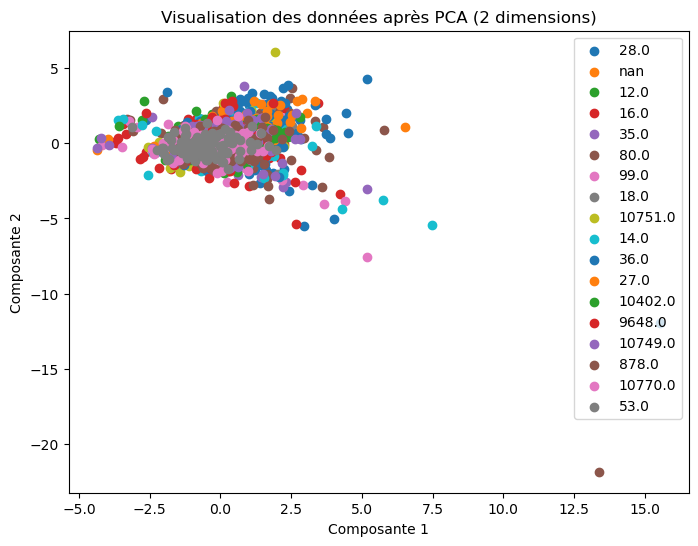

,Composante 1,Composante 2,classe
0,1.144472,1.156906,28.0
1,15.564669,-11.964552,28.0


In [32]:
dfacp= gp.genreacp(df1,2)
dfacp.head(2)

Globalement, pas grand chose d'évident. 

## B - Prédire le genre grâce à des Forêts Aléatoires

On va maintenant utiliser un modèle classique de Machine Learning pour prédire le genre: les forêts aléatoires. 

On commence par un modèle qui ne prend en compte que les données numériques

In [33]:
X=df1.drop(columns=['id','overview','release_date', 'title', 'main_genre_name', "full_poster_path", "main_genre_id"])
y=df1['main_genre_name']

rf_num_full=gp.rfnum(X,y, random_state=1)

Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.28      0.24      0.25        34
      Adventure       0.25      0.26      0.25        39
      Animation       0.44      0.50      0.47        34
         Comedy       0.49      0.54      0.51        35
          Crime       0.16      0.11      0.13        36
    Documentary       0.38      0.50      0.43        26
          Drama       0.38      0.47      0.42        38
         Family       0.30      0.48      0.37        27
        Fantasy       0.14      0.07      0.10        42
        History       0.30      0.34      0.32        32
         Horror       0.36      0.26      0.30        39
          Music       0.55      0.46      0.50        35
        Mystery       0.14      0.09      0.11        35
        Romance       0.37      0.17      0.23        42
Science Fiction       0.22      0.35      0.27        31
       TV Movie       0.20      0.17      0.19        23
  

L'échantillon équilibré fait que le modèle essaye de prédire chaque genre. On observe une réelle différence de performance entre les différents genre. 

Dans ce modèle, la date est la variable qui contribue le plus de prédire le genre. Suivent ensuite la popularité et la longueur du film. Étonnamment, la longueur du titre et du synopsis aident tout autant à prédire le genre du film. 

On peut ensuite appliquer les forêts aléatoires à la matrice TF-IDF du synopsis des films. 

In [34]:
X = df1['overview']
y = df1['main_genre_name']

rf_nlp, vectorizer, label_encoder=gp.rfnlp(X,y, random_state=1)


Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.22      0.15      0.18        34
      Adventure       0.41      0.23      0.30        39
      Animation       0.16      0.29      0.21        34
         Comedy       0.54      0.43      0.48        35
          Crime       0.27      0.22      0.24        36
    Documentary       0.30      0.27      0.29        26
          Drama       0.09      0.05      0.07        38
         Family       0.23      0.22      0.23        27
        Fantasy       0.04      0.02      0.03        42
        History       0.45      0.28      0.35        32
         Horror       0.35      0.38      0.37        39
          Music       0.64      0.80      0.71        35
        Mystery       0.18      0.17      0.18        35
        Romance       0.22      0.24      0.23        42
Science Fiction       0.27      0.45      0.34        31
       TV Movie       0.00      0.00      0.00        23
 

On a des résultats légèrement moins bons qu'avec les variables numériques. 

On peut voir pour chaque genre, quels mots permettent le mieux de le prédire:

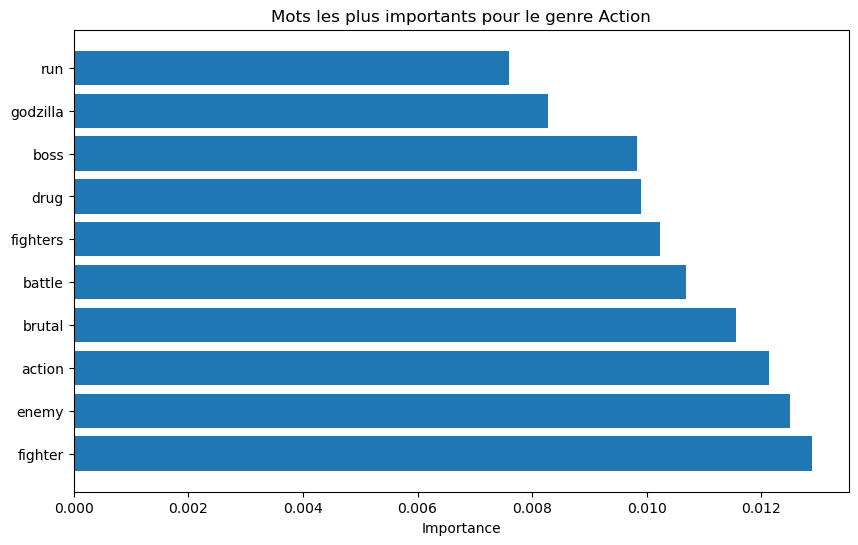

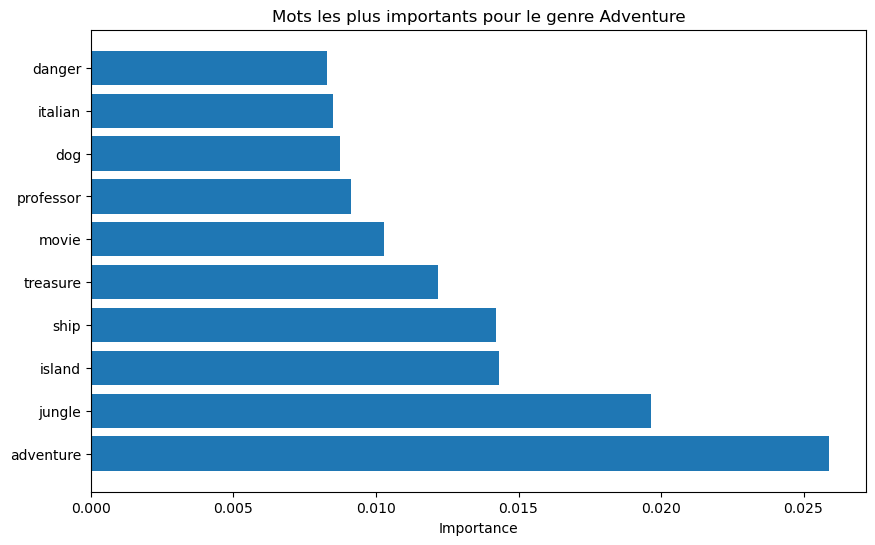

In [35]:
#Pour les voir tous:
# gp.plot_important_words_for_genre(range(len(rf_nlp.estimators_)), rf_nlp, vectorizer, label_encoder)

gp.plot_important_words_for_genre([0,1], rf_nlp, vectorizer, label_encoder)

Ces mots sont plutôt cohérents!

Enfin, grâce aux pipelines on peut combiner ces deux méthodes pour obtenir de bien meilleurs scores de précision!

In [36]:
gp.super_model(df1, random_state=1)


Rapport de classification :
                 precision    recall  f1-score   support

         Action       0.52      0.35      0.42        34
      Adventure       0.76      0.97      0.85        39
      Animation       0.61      0.82      0.70        34
         Comedy       0.79      0.54      0.64        35
          Crime       0.59      0.28      0.38        36
    Documentary       0.69      0.85      0.76        26
          Drama       0.61      0.71      0.66        38
         Family       0.49      0.63      0.55        27
        Fantasy       0.70      0.55      0.61        42
        History       0.53      0.56      0.55        32
         Horror       0.55      0.54      0.55        39
          Music       0.94      0.89      0.91        35
        Mystery       0.47      0.43      0.45        35
        Romance       0.62      0.55      0.58        42
Science Fiction       0.44      0.71      0.54        31
       TV Movie       1.00      0.13      0.23        23
 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text', TfidfVectorizer(),
                                                  'overview'),
                                                 ('num', StandardScaler(),
                                                  Index(['budget', 'popularity', 'revenue', 'runtime', 'vote_average',
       'vote_count', 'main_genre_id', 'overview_count', 'title_count',
       'timestamp'],
      dtype='object'))])),
                ('classifier', RandomForestClassifier(random_state=1))])